# NB11c: Cross-validation Rigor + Statistical Inference v2

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Statistical-rigor consumer for the OOF predictions. Unlike NB11a (point estimates on overlap) and NB11b (visualization), this notebook quantifies **uncertainty** and **sensitivity** without retraining any upstream model. Everything comes from the existing `oof_*.parquet` files.

Sections:
- **M1 DISCOVERY** — find OOF parquets (same glob as NB11a/12b)
- **M2 LOAD + DEDUP** — concat + keep latest per `model_id`
- **M3 PER-FOLD AUC STABILITY** — per-model per-fold AUC (from stored `fold_id`), box plots, model × fold heatmap, hard-fold detection
- **M4 BOOTSTRAP CI on pairwise Cohen's κ** — resample buildings with replacement; 95% CI on agreement between top-N models
- **M5 BOOTSTRAP CI on Jaccard FP / FN** — same treatment on error sets
- **M6 BOOTSTRAP CI on Fleiss' κ** — multi-rater reliability with uncertainty
- **M7 PAIRED BOOTSTRAP: leakage delta significance** — for matched clean-vs-leaky pairs, 95% CI on AUC inflation. Does the CI exclude zero?
- **M8 LABEL NOISE SENSITIVITY** — flip p ∈ {0.01, 0.05, 0.10, 0.20} of `y_true` labels, recompute per-model AUC rankings + Jaccard. Speaks to the UNOSAT = Achilles Heel framing (Aimaiti 2022)
- **M9 SUMMARY** — CSV artefacts for the thesis statistical-rigor chapter

What's NOT in here (deliberately):
- Nested CV for hyperparameter selection — requires retraining; belongs in NB09 or a branch
- K-fold refit with different seeds — same reason
- Calibration analysis (reliability diagrams) — possible from `y_proba` but scoped out of v2

# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB11c CONFIG + GLOBAL SETUP
import sys, os
from pathlib import Path

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

# --- tier / city selection (match upstream notebooks) ------------------
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42

# --- OOF discovery roots ---------------------------------------------
OOF_SEARCH_ROOTS = [RESULTS_ROOT]
try:
    _nb09d_root = CONTENT_LOCAL / 'nb09d_dl_experiments'
    if _nb09d_root.exists():
        OOF_SEARCH_ROOTS.append(_nb09d_root)
except NameError:
    pass

# --- NB11 hyperparameter-tuning OOF parquets (added in v6) ----------
try:
    _nb11_root = OUTPUTS_DIR / 'NB11_V2' / 'oof'
    if _nb11_root.exists():
        OOF_SEARCH_ROOTS.append(_nb11_root)
except NameError:
    pass

# --- leakage-variant markers (same as NB11a) -------------------------
LEAKAGE_VARIANT_MARKERS = ['leakage_demo', 'random_cv', 'geographic_70_30']

# --- bootstrap config -----------------------------------------------
# B = number of bootstrap resamples per statistic
# Start at 500 for iteration; bump to 2000-10000 for final thesis tables
B_BOOTSTRAP = 500
BOOTSTRAP_CI_LEVEL = 0.95  # 95% CI (percentile method)

# Cap number of models for pairwise bootstrap (complexity = O(N^2 * B))
# 15 models -> 105 pairs -> 105 * 500 = 52500 kappa computations -> ~1-2 min
TOP_N_MODELS_FOR_BOOTSTRAP = 15

# --- label noise sensitivity ----------------------------------------
LABEL_NOISE_RATES = [0.01, 0.05, 0.10, 0.20]
LABEL_NOISE_N_REPS = 20   # repetitions per noise rate for variance

# --- per-fold analysis ----------------------------------------------
# min fold size (n buildings) to compute AUC for that fold
MIN_FOLD_SIZE = 50

print(f"  OOF search roots:")
for r in OOF_SEARCH_ROOTS:
    print(f"    {r}")
print(f"  TIER_SELECTION:              {TIER_SELECTION}")
print(f"  B_BOOTSTRAP:                 {B_BOOTSTRAP}")
print(f"  TOP_N_MODELS_FOR_BOOTSTRAP:  {TOP_N_MODELS_FOR_BOOTSTRAP}")
print(f"  LABEL_NOISE_RATES:           {LABEL_NOISE_RATES}")
print(f"  LABEL_NOISE_N_REPS:          {LABEL_NOISE_N_REPS}")
print(f"  RANDOM_STATE:                {RANDOM_STATE}")


BDA GLOBAL SETUP
Started: 2026-07-03 08:43:38
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.7/7452.0 GB (6521.3 GB free)
  GDrive (F:)     1405.7/3726.0 GB (2320.3 GB free)
  Local data      11563.4/14901.9 GB (3338.4 GB free)
  Data stack      1405.7/3726.0 GB (2320.3 GB free)
  WSL ext4        69.1/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: BUILDINGS + OUTPUT PATHS + HELPERS

In [2]:
# @title CELL S0: SETUP (A/B GROUPS + MODALITY)
import json, gc, time, re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime as _dt
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB11c CV RIGOR -- SETUP (A/B GROUPS + MODALITY)")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import oof_loader
import importlib
importlib.reload(oof_loader)
from oof_loader import (
    GROUP_A, GROUP_B, SAMPLE_ID_COL,
    discover_oof_parquets, load_all_oof,
    load_metadata_both, check_y_true_consistency,
    build_model_sanity,
)

CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
DATASET_ROOT_V3 = STACK_DIR / 'dataset' / 'v3'

meta = load_metadata_both(
    dataset_root_v2=DATASET_ROOT_V2,
    dataset_root_v3=DATASET_ROOT_V3,
    tiers=_tiers,
    cities=CITIES_TO_PROCESS,
    load_tier_parquets_fn=load_tier_parquets,
)

# --- modality classifier (reused from NB11a M11) ---------------------
def classify_modality(model_id, variant_id):
    combined = (str(model_id) + ' ' + str(variant_id)).lower()
    # --- NB11 explicit parquet -> modality lookup (added in v6) --------
    # NB11 model_ids look like 'NB11<a-f>_<tag>__<manifest_key>__<clf>-Optuna'.
    # We check manifest_key tokens FIRST so they take precedence over the
    # token-substring matchers below (which would otherwise miss 'fusion_*').
    _nb11_modality = {
        # SAR-only
        'card_drop':                  'SAR_card_only',
        'prepost_single_card':        'SAR_card_only',
        'coh_drop':                   'SAR_coh_only',
        'rolling_accum_coh':          'SAR_coh_only',
        # SAR + COH fused (no MS)
        'fusion_card_cohdrop':        'SAR_card+coh',
        # multimodal (SAR + MS, +/- COH)
        'fusion_ms_card_cohdrop':     'multimodal_all',
        'fusion_indices_card_cohdrop':'multimodal_all',
        'fusion_ms_cohdrop':          'multimodal_SAR+MS',
        'fusion_composite_cohdrop':   'multimodal_all',
        'fusion_composite_blockstats':'multimodal_all',
        'block_stats':                'multimodal_all',
        'rolling_stats_roll3':        'multimodal_all',
        'rolling_stats_roll7':        'multimodal_all',
        'rolling_stats_roll13':       'multimodal_all',
        # MS-only
        'ms_change':                  'MS_only',
        'composite_prepost_bands':    'MS_only',
        'composite_vs_scenes_bands':  'MS_only',
        # land-use (own family)
        'lu_change':                  'other',
        'composite_prepost_landuse':  'other',
        'composite_vs_scenes_landuse':'other',
    }
    if 'nb11' in combined:
        for _key, _mod in _nb11_modality.items():
            if _key in combined:
                return _mod
    if any(x in combined for x in ['coh_drop', 'coh_running', 'coh_max_drop']):
        return 'SAR_coh_unsupervised'
    if 'logratio' in combined:
        if any(x in combined for x in ['ndvi', 'savi', 'bsi', 'nbr', 'ndbi']):
            return 'MS_unsupervised'
        return 'SAR_unsupervised'
    if 'card_only' in combined or 'sensor=card;' in combined or combined.endswith('sensor=card'):
        return 'SAR_card_only'
    if 'coh_only' in combined or 'sensor=coh;' in combined or combined.endswith('sensor=coh'):
        return 'SAR_coh_only'
    if 'card+coh' in combined or 'sensor=card+coh' in combined:
        return 'SAR_card+coh'
    if 'ms_only' in combined or 'sensor=ms' in combined:
        return 'MS_only'
    if 'nb08b' in combined:
        if 'rgb' in combined and ('card' in combined or 'coh' in combined):
            return 'multimodal_SAR+MS'
        if 'rgb' in combined:
            return 'MS_only'
    if 'all_multimodal' in combined or 'all features' in combined:
        return 'multimodal_all'
    if 'parquet=f7' in combined or 'parquet=a17' in combined:
        return 'multimodal_all'
    if 'sar_only' in combined:
        return 'SAR_all'
    if 'sar + ms + coh' in combined:
        return 'multimodal_all'
    if 'sar + ms' in combined:
        return 'multimodal_SAR+MS'
    return 'other'

MODALITY_FAMILIES = {
    'SAR': ['SAR_card_only', 'SAR_coh_only', 'SAR_card+coh', 'SAR_all',
            'SAR_coh_unsupervised', 'SAR_unsupervised'],
    'MS':  ['MS_only', 'MS_unsupervised'],
    'multimodal': ['multimodal_all', 'multimodal_SAR+MS'],
}

def modality_family(mod):
    for fam, members in MODALITY_FAMILIES.items():
        if mod in members:
            return fam
    return 'other'

# --- output ---
OUT_DIR = RESULTS_ROOT / 'nb11c'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150, show=True):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

def pct_ci(arr, ci=95):
    clean = arr[~np.isnan(arr)]
    if len(clean) == 0:
        return np.nan, np.nan, np.nan
    lo = np.percentile(clean, (100 - ci) / 2)
    hi = np.percentile(clean, 100 - (100 - ci) / 2)
    return float(np.mean(clean)), float(lo), float(hi)

rng = np.random.default_rng(RANDOM_STATE)

print(f"  Output: {OUT_DIR}")


CELL S0: NB11c CV RIGOR -- SETUP (A/B GROUPS + MODALITY)
  load_tier_parquets: 3 tiers, 907371 rows
  V2 buildings: 598,595  (damaged=7,332)
  load_tier_parquets: 3 tiers, 63243 rows
  v3 points: 63,243  (damaged=8,247)  [from v3]
  Output: /content/drive_f/masterthesis/results/nb11c


# CELL M1: DISCOVERY — GLOB OOF PARQUETS

In [3]:
# @title CELL M1: DISCOVERY
print("=" * 70)
print("CELL M1: DISCOVER OOF PARQUETS")
print("=" * 70)

inv_df = discover_oof_parquets(OOF_SEARCH_ROOTS)
save_result(inv_df.drop(columns=['path'], errors='ignore'), 'M1_oof_inventory', 'cell_m1')


CELL M1: DISCOVER OOF PARQUETS
  /content/drive_f/masterthesis/results: 925 parquets
  /content/masterthesis_local/nb09d_dl_experiments: 116 parquets
  /content/drive_f/masterthesis/data/outputs/NB11_V2/oof: 47 parquets

  Total: 1088 OOF parquet files discovered

  Breakdown by group:
    buildings_v2             :  654 parquets  (342 unique model_ids)
    points_v3plus            :  434 parquets  (219 unique model_ids)

  Breakdown by notebook:
    nb07                               :  157 parquets  (40 unique model_ids)
    nb07v3                             :   41 parquets  (41 unique model_ids)
    nb08                               :   49 parquets  (26 unique model_ids)
    nb08b                              :   77 parquets  (72 unique model_ids)
    nb09a                              :   45 parquets  (45 unique model_ids)
    nb09a_v3                           :   96 parquets  (48 unique model_ids)
    nb09a_v4                           :   48 parquets  (48 unique model_ids)
   

PosixPath('/content/drive_f/masterthesis/results/nb11c/cell_m1/M1_oof_inventory_20260703_084626.csv')

# CELL M2: LOAD + DEDUP + AUC SANITY
Latest per model_id. Computes overall AUC and flags leaky / degenerate.

In [4]:
# @title CELL M2: LOAD + DEDUP + MODEL SANITY (A/B GROUPS + MODALITY)
print("=" * 70)
print("CELL M2: LOAD + DEDUP + SANITY")
print("=" * 70)

oof_A, oof_B = load_all_oof(inv_df)

groups_loaded = {}
if oof_A is not None and len(oof_A) > 0:
    groups_loaded[GROUP_A] = oof_A
if oof_B is not None and len(oof_B) > 0:
    groups_loaded[GROUP_B] = oof_B

model_sanity_all = {}
headline_all = {}

for grp_name, grp_oof in groups_loaded.items():
    check_y_true_consistency(grp_oof, grp_name)
    ms = build_model_sanity(grp_oof, grp_name, LEAKAGE_VARIANT_MARKERS)
    ms['modality'] = ms.apply(lambda r: classify_modality(r['model_id'], r['variant_id']), axis=1)
    ms['modality_family'] = ms['modality'].apply(modality_family)
    model_sanity_all[grp_name] = ms

    headline = sorted(ms.loc[(~ms['is_leaky']) & (~ms['is_degenerate']), 'model_id'])
    headline_all[grp_name] = headline
    print(f"  [{grp_name}] headline={len(headline)}, leaky={int(ms['is_leaky'].sum())}, "
          f"degenerate={int(ms['is_degenerate'].sum())}")

    # modality breakdown
    print(f"\n  [{grp_name}] modality breakdown:")
    for fam in ['SAR', 'MS', 'multimodal', 'other']:
        sub = ms[(ms['modality_family'] == fam) & (~ms['is_leaky']) & (~ms['is_degenerate'])]
        if len(sub) > 0:
            print(f"    {fam:15s}: {len(sub):3d} models  AUC median={sub['auc'].median():.3f}  "
                  f"max={sub['auc'].max():.3f}")

    save_result(ms, f'M2_model_sanity_{grp_name}', 'cell_m2')

print(f"\n  Groups loaded: {list(groups_loaded.keys())}")


CELL M2: LOAD + DEDUP + SANITY
LOAD OOF + DEDUP + NORMALIZE
  buildings_v2: 654 parquets -> 342 after dedup
    Loaded 147,445,440 rows, 342 models, 756,443 unique samples, 54 cities
  points_v3plus: 434 parquets -> 219 after dedup
    Loaded 12,412,796 rows, 219 models, 104,130 unique samples, 21 cities
  WARNING [buildings_v2]: 7332 samples have inconsistent y_true across models
  [buildings_v2] 342 models: 4 leaky, 34 degenerate
  [buildings_v2] headline=304, leaky=4, degenerate=34

  [buildings_v2] modality breakdown:
    SAR            :  69 models  AUC median=0.625  max=0.846
    MS             :  30 models  AUC median=0.659  max=0.818
    multimodal     :  64 models  AUC median=0.748  max=0.865
    other          : 141 models  AUC median=0.594  max=0.843
  Saved: cell_m2/M2_model_sanity_buildings_v2_20260703_084944.csv (53.4 KB)
  WARNING [points_v3plus]: 10567 samples have inconsistent y_true across models
  [points_v3plus] 219 models: 4 leaky, 5 degenerate
  [points_v3plus] he

# CELL M3: PER-FOLD AUC STABILITY
Uses the stored `fold_id` in each OOF parquet. Per model × per fold:
- AUC (if fold has both classes and >= MIN_FOLD_SIZE buildings)
- Reports mean ± std across folds, CV (coefficient of variation = std/mean)

High CV (>10%) signals unstable learning — model performance depends heavily on which city landed in which fold. Flat per-fold AUC is a good sign.

Models with only 1 fold (unsupervised, stacking meta-learner, train/test holdout-style) are excluded from this section — they have no CV structure to analyze.

CELL M3: PER-FOLD AUC STABILITY

  === buildings_v2 ===
  Saved: cell_m3/M3_per_fold_auc_long_buildings_v2_20260703_101708.csv (115.2 KB)
  Saved: cell_m3/M3_per_model_stability_buildings_v2_20260703_101709.csv (20.7 KB)

  [buildings_v2] stability by modality family:
    MS             : n= 26  mean_CV=0.120  mean_range=0.191
    SAR            : n= 54  mean_CV=0.135  mean_range=0.193
    multimodal     : n= 64  mean_CV=0.149  mean_range=0.232
    other          : n= 97  mean_CV=0.142  mean_range=0.199

  Per-fold avg AUC:
           mean     std  count
fold_id                       
1        0.5726  0.1043    241
0        0.5995  0.1382    241
2        0.6089  0.0967    241
3        0.6156  0.0982    241
4        0.6593  0.1222    239
  Saved: cell_m3/M3_fold_difficulty_buildings_v2_20260703_101709.csv (0.1 KB)


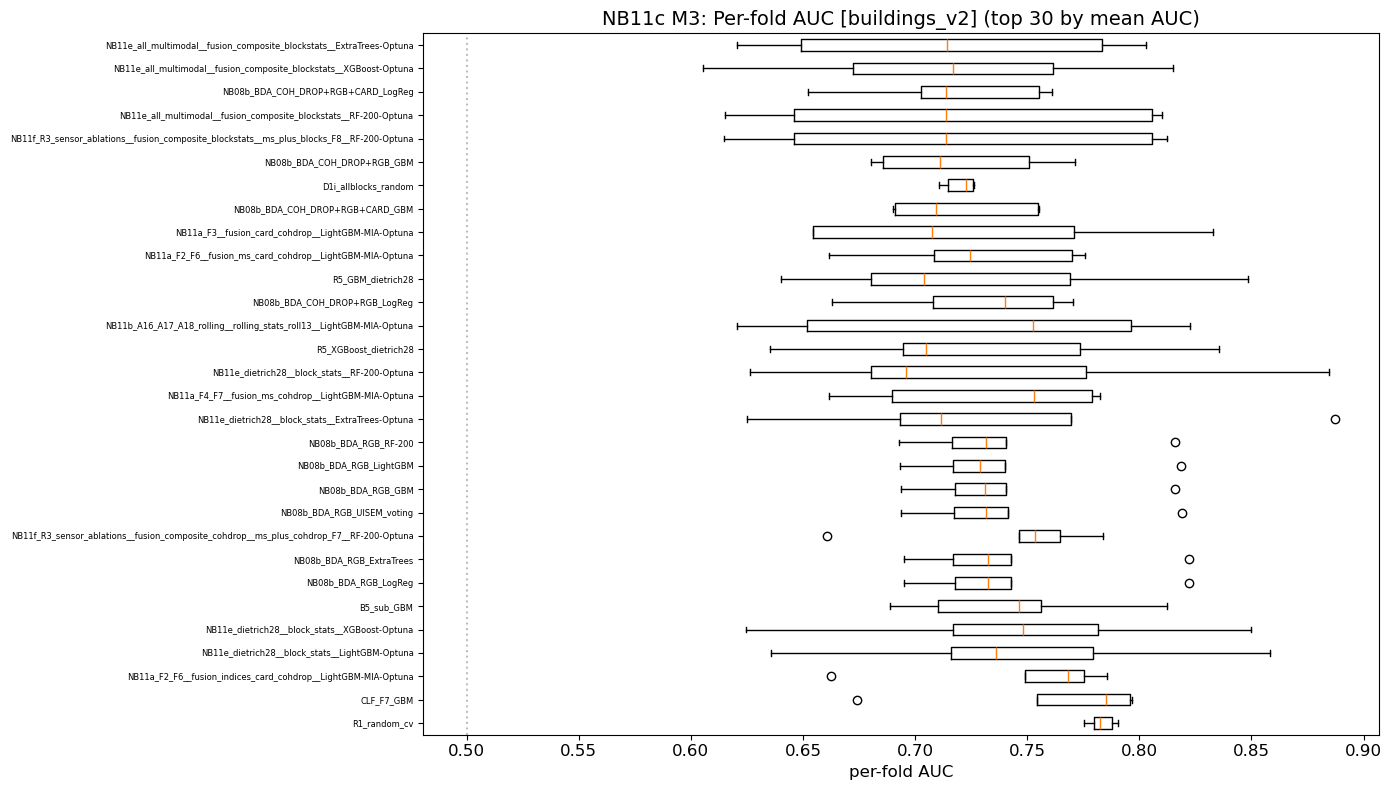

  Plot: cell_m3/M3_per_fold_boxplot_buildings_v2_20260703_101710.png

  === points_v3plus ===
  Saved: cell_m3/M3_per_fold_auc_long_points_v3plus_20260703_102140.csv (63.6 KB)
  Saved: cell_m3/M3_per_model_stability_points_v3plus_20260703_102140.csv (10.9 KB)

  [points_v3plus] stability by modality family:
    MS             : n=  6  mean_CV=0.056  mean_range=0.087
    SAR            : n= 19  mean_CV=0.070  mean_range=0.088
    multimodal     : n= 26  mean_CV=0.053  mean_range=0.086
    other          : n= 94  mean_CV=0.055  mean_range=0.079

  Per-fold avg AUC:
           mean     std  count
fold_id                       
2        0.5684  0.0483    145
1        0.5828  0.0820    145
3        0.5931  0.0670    145
0        0.5951  0.0856    145
4        0.6081  0.0765    141
  Saved: cell_m3/M3_fold_difficulty_points_v3plus_20260703_102140.csv (0.1 KB)


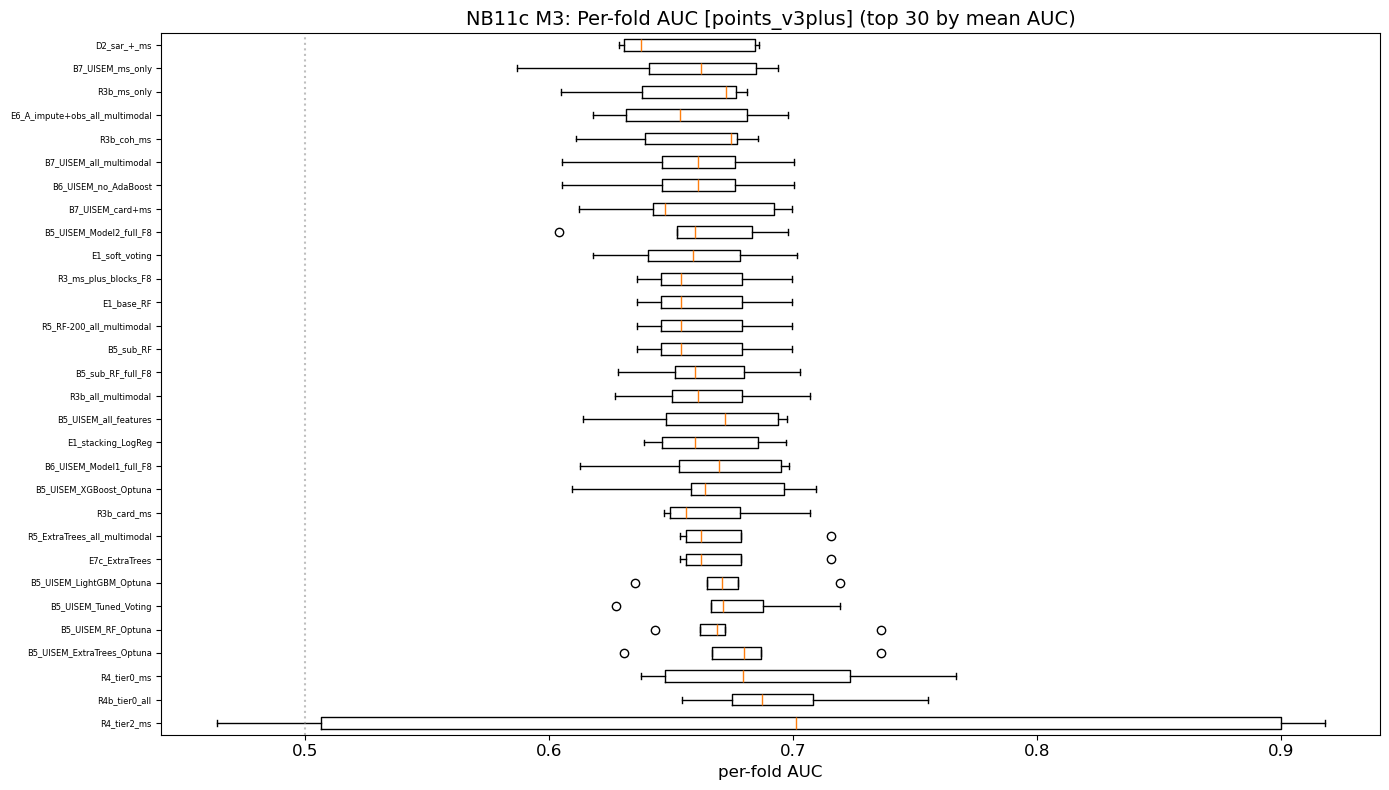

  Plot: cell_m3/M3_per_fold_boxplot_points_v3plus_20260703_102140.png


In [5]:
# @title CELL M3: PER-FOLD AUC STABILITY (PER GROUP + MODALITY)
print("=" * 70)
print("CELL M3: PER-FOLD AUC STABILITY")
print("=" * 70)

per_fold_all = {}
per_model_stability_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    multi_fold = ms[(~ms['is_degenerate']) & (ms.get('n_samples', ms.get('n', 0)) > 0)]
    multi_fold_mids = multi_fold['model_id'].tolist()

    rows = []
    for mid in multi_fold_mids:
        model_df = grp_oof[grp_oof['model_id'] == mid]
        if 'fold_id' not in model_df.columns or model_df['fold_id'].nunique() < 2:
            continue
        for fid, g in model_df.groupby('fold_id'):
            yt = g['y_true'].values
            ypr = g['y_proba'].values
            n = len(g)
            n_dmg = int((yt == 1).sum())
            auc = np.nan
            if n >= MIN_FOLD_SIZE and 0 < n_dmg < n:
                try:
                    auc = float(roc_auc_score(yt, ypr))
                except Exception:
                    pass
            rows.append({
                'model_id': mid, 'fold_id': int(fid), 'n': n,
                'n_damaged': n_dmg, 'auc': auc,
                'cities': '|'.join(sorted(g['city'].unique())),
                'n_cities': g['city'].nunique(),
            })

    if not rows:
        print(f"  [{grp_name}] no multi-fold models, skipping")
        continue

    per_fold = pd.DataFrame(rows)
    save_result(per_fold, f'M3_per_fold_auc_long_{grp_name}', 'cell_m3')

    # per-model stability
    stab_rows = []
    for mid, g in per_fold.groupby('model_id'):
        aucs = g['auc'].dropna().values
        if len(aucs) < 2:
            continue
        mod_info = ms[ms['model_id'] == mid].iloc[0]
        stab_rows.append({
            'model_id': mid, 'modality': mod_info['modality'],
            'modality_family': mod_info['modality_family'],
            'n_folds': len(aucs),
            'auc_mean': round(float(aucs.mean()), 4),
            'auc_std': round(float(aucs.std(ddof=1)), 4),
            'auc_cv': round(float(aucs.std(ddof=1) / aucs.mean()), 4) if aucs.mean() > 0 else np.nan,
            'auc_min': round(float(aucs.min()), 4),
            'auc_max': round(float(aucs.max()), 4),
            'auc_range': round(float(aucs.max() - aucs.min()), 4),
        })

    stab = pd.DataFrame(stab_rows).sort_values('auc_mean', ascending=False)
    per_fold_all[grp_name] = per_fold
    per_model_stability_all[grp_name] = stab
    save_result(stab, f'M3_per_model_stability_{grp_name}', 'cell_m3')

    # stability by modality family
    print(f"\n  [{grp_name}] stability by modality family:")
    for fam, fsub in stab.groupby('modality_family'):
        if len(fsub) > 0:
            print(f"    {fam:15s}: n={len(fsub):3d}  mean_CV={fsub['auc_cv'].mean():.3f}  "
                  f"mean_range={fsub['auc_range'].mean():.3f}")

    # fold difficulty
    fold_diff = per_fold.groupby('fold_id')['auc'].agg(['mean', 'std', 'count']).round(4)
    fold_diff = fold_diff.sort_values('mean')
    print(f"\n  Per-fold avg AUC:")
    print(fold_diff.to_string())
    save_result(fold_diff.reset_index(), f'M3_fold_difficulty_{grp_name}', 'cell_m3')

    # boxplot
    top30 = stab.head(30)['model_id'].tolist()
    data_box = [per_fold[per_fold['model_id'] == m]['auc'].dropna().values for m in top30]
    fig, ax = plt.subplots(figsize=(14, max(8, len(top30) * 0.2)))
    ax.boxplot(data_box, labels=top30, vert=False)
    ax.set_xlabel('per-fold AUC')
    ax.set_title(f'NB11c M3: Per-fold AUC [{grp_name}] (top 30 by mean AUC)')
    ax.tick_params(axis='y', labelsize=6)
    ax.axvline(0.5, color='grey', ls=':', alpha=0.5)
    plt.tight_layout()
    save_fig(fig, f'M3_per_fold_boxplot_{grp_name}', 'cell_m3')


# CELL M4: BOOTSTRAP CI on PAIRWISE COHEN's κ
Resample buildings with replacement B times, recompute κ on each bootstrap. Report mean + 95% CI per pair.

Wide CI → uncertain agreement (often driven by small FP/FN sets). Narrow CI that doesn't include zero → robust agreement signal.

Restricted to top-N models by AUC (complexity = O(N^2 × B)).

In [6]:
# @title CELL M4: BOOTSTRAP CI on PAIRWISE COHEN's kappa (PER GROUP)
from sklearn.metrics import cohen_kappa_score

print("=" * 70)
print(f"CELL M4: BOOTSTRAP CI on COHEN's kappa  (B={B_BOOTSTRAP}, top-{TOP_N_MODELS_FOR_BOOTSTRAP})")
print("=" * 70)

kappa_ci_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]
    top_for_boot = headline.nlargest(TOP_N_MODELS_FOR_BOOTSTRAP, 'auc')['model_id'].tolist()
    print(f"  Top-{len(top_for_boot)} models:")
    for m in top_for_boot:
        r = ms[ms['model_id'] == m].iloc[0]
        print(f"    {r['auc']:.4f}  [{r['modality_family']:12s}]  {m}")

    pred_by_model = {}
    for m in top_for_boot:
        g = grp_oof[grp_oof['model_id'] == m][[SAMPLE_ID_COL, 'y_pred']].drop_duplicates(SAMPLE_ID_COL)
        pred_by_model[m] = g.set_index(SAMPLE_ID_COL)['y_pred']

    kappa_rows = []
    t0 = time.time()
    pair_count = 0
    total_pairs = len(top_for_boot) * (len(top_for_boot) - 1) // 2

    for i, m1 in enumerate(top_for_boot):
        for j, m2 in enumerate(top_for_boot):
            if j <= i:
                continue
            pair_count += 1
            common_ids = pred_by_model[m1].index.intersection(pred_by_model[m2].index)
            if len(common_ids) < 50:
                kappa_rows.append({'model_a': m1, 'model_b': m2, 'n_common': len(common_ids),
                                   'kappa_mean': np.nan, 'kappa_lo': np.nan, 'kappa_hi': np.nan})
                continue
            a = pred_by_model[m1].loc[common_ids].astype(int).values
            b = pred_by_model[m2].loc[common_ids].astype(int).values
            try:
                k_point = float(cohen_kappa_score(a, b))
            except Exception:
                k_point = np.nan
            n = len(common_ids)
            boot_kappas = np.full(B_BOOTSTRAP, np.nan)
            for bi in range(B_BOOTSTRAP):
                idx = rng.integers(0, n, size=n)
                try:
                    boot_kappas[bi] = cohen_kappa_score(a[idx], b[idx])
                except Exception:
                    pass
            mean, lo, hi = pct_ci(boot_kappas)
            mod_a = ms.loc[ms['model_id'] == m1, 'modality_family'].iloc[0]
            mod_b = ms.loc[ms['model_id'] == m2, 'modality_family'].iloc[0]
            kappa_rows.append({
                'model_a': m1, 'model_b': m2, 'mod_family_a': mod_a, 'mod_family_b': mod_b,
                'n_common': int(n), 'kappa_point': round(k_point, 4) if not np.isnan(k_point) else np.nan,
                'kappa_mean': round(mean, 4), 'kappa_lo': round(lo, 4), 'kappa_hi': round(hi, 4),
                'kappa_ci_width': round(hi - lo, 4),
            })
        if (i + 1) % 5 == 0 or i == len(top_for_boot) - 1:
            print(f"    progress: {pair_count}/{total_pairs} pairs  ({time.time()-t0:.1f}s)")

    kdf = pd.DataFrame(kappa_rows)
    kappa_ci_all[grp_name] = kdf
    save_result(kdf, f'M4_pairwise_kappa_bootstrap_{grp_name}', 'cell_m4')

    # summary by modality pair type
    valid = kdf.dropna(subset=['kappa_ci_width'])
    if len(valid) > 0:
        valid['pair_type'] = valid.apply(
            lambda r: f"{r['mod_family_a']}-{r['mod_family_b']}" if r['mod_family_a'] <= r['mod_family_b']
            else f"{r['mod_family_b']}-{r['mod_family_a']}", axis=1)
        print(f"\n  [{grp_name}] kappa by modality pair type:")
        for pt, pg in valid.groupby('pair_type'):
            print(f"    {pt:30s}: n={len(pg):3d}  mean_kappa={pg['kappa_mean'].mean():.3f}")


CELL M4: BOOTSTRAP CI on COHEN's kappa  (B=500, top-15)

  === buildings_v2 ===
  Top-15 models:
    0.8652  [multimodal  ]  NB11e_dietrich28__block_stats__LightGBM-Optuna
    0.8565  [multimodal  ]  NB11e_dietrich28__block_stats__XGBoost-Optuna
    0.8531  [multimodal  ]  NB11b_A15_block_stats__block_stats__LightGBM-MIA-Optuna
    0.8514  [multimodal  ]  NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA-Optuna
    0.8514  [multimodal  ]  NB11b_A16_A17_A18_rolling__rolling_stats_roll7__LightGBM-MIA-Optuna
    0.8471  [multimodal  ]  NB11a_F2_F6__fusion_indices_card_cohdrop__LightGBM-MIA-Optuna
    0.8457  [SAR         ]  NB11a_F3__fusion_card_cohdrop__LightGBM-MIA-Optuna
    0.8452  [multimodal  ]  NB11e_dietrich28__block_stats__RF-200-Optuna
    0.8449  [multimodal  ]  NB11a_F4_F7__fusion_composite_cohdrop__LightGBM-MIA-Optuna
    0.8430  [other       ]  NB11c_A22_lu_change__lu_change__LightGBM-MIA-Optuna
    0.8422  [multimodal  ]  NB11e_dietrich28__block_stats__ExtraTrees-Optuna
    0.84

# CELL M5: BOOTSTRAP CI on JACCARD FP / FN
Same pattern as M4: for each pair of top models, B resamples of buildings, recompute Jaccard on FP sets and on FN sets separately, report 95% CI.

The FP sets are small (hundreds to low thousands per model); their Jaccard is sensitive to resampling. Wide CIs on FP Jaccard are expected. FN sets are usually larger, giving tighter CIs.

In [7]:
# @title CELL M5: BOOTSTRAP CI on JACCARD FP / FN (PER GROUP + MODALITY)
print("=" * 70)
print(f"CELL M5: BOOTSTRAP CI on JACCARD FP / FN  (B={B_BOOTSTRAP})")
print("=" * 70)

def jaccard_from_mask(mask_a, mask_b):
    inter = int(np.logical_and(mask_a, mask_b).sum())
    un = int(np.logical_or(mask_a, mask_b).sum())
    return inter / un if un > 0 else np.nan

jac_ci_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]
    top_for_boot = headline.nlargest(TOP_N_MODELS_FOR_BOOTSTRAP, 'auc')['model_id'].tolist()
    mod_lookup = dict(zip(ms['model_id'], ms['modality_family']))

    cm_by_model = {}
    for m in top_for_boot:
        g = grp_oof[grp_oof['model_id'] == m][[SAMPLE_ID_COL, 'cm_class']].drop_duplicates(SAMPLE_ID_COL)
        cm_by_model[m] = g.set_index(SAMPLE_ID_COL)['cm_class']

    jac_rows = []
    t0 = time.time()
    for i, m1 in enumerate(top_for_boot):
        for j, m2 in enumerate(top_for_boot):
            if j <= i:
                continue
            common_ids = cm_by_model[m1].index.intersection(cm_by_model[m2].index)
            if len(common_ids) < 50:
                continue
            cm_a = cm_by_model[m1].loc[common_ids].values
            cm_b = cm_by_model[m2].loc[common_ids].values
            fp_a = (cm_a == 'FP'); fp_b = (cm_b == 'FP')
            fn_a = (cm_a == 'FN'); fn_b = (cm_b == 'FN')
            n = len(common_ids)
            bfp = np.full(B_BOOTSTRAP, np.nan)
            bfn = np.full(B_BOOTSTRAP, np.nan)
            for bi in range(B_BOOTSTRAP):
                idx = rng.integers(0, n, size=n)
                bfp[bi] = jaccard_from_mask(fp_a[idx], fp_b[idx])
                bfn[bi] = jaccard_from_mask(fn_a[idx], fn_b[idx])
            mfp, lfp, hfp = pct_ci(bfp)
            mfn, lfn, hfn = pct_ci(bfn)
            f1 = mod_lookup.get(m1, 'other')
            f2 = mod_lookup.get(m2, 'other')
            pt = f"{min(f1,f2)}-{max(f1,f2)}"
            jac_rows.append({
                'model_a': m1, 'model_b': m2,
                'mod_family_a': f1, 'mod_family_b': f2, 'pair_type': pt,
                'n_common': int(n),
                'jac_fp_mean': round(mfp, 4), 'jac_fp_lo': round(lfp, 4), 'jac_fp_hi': round(hfp, 4),
                'jac_fn_mean': round(mfn, 4), 'jac_fn_lo': round(lfn, 4), 'jac_fn_hi': round(hfn, 4),
            })

    jdf = pd.DataFrame(jac_rows)
    jac_ci_all[grp_name] = jdf
    print(f"  Done in {time.time()-t0:.1f}s  ({len(jdf)} pairs)")

    if len(jdf) > 0:
        print(f"  Overall: Jaccard FN mean={jdf['jac_fn_mean'].mean():.3f}  FP mean={jdf['jac_fp_mean'].mean():.3f}")
        print(f"\n  [{grp_name}] Jaccard by modality pair type:")
        for pt, pg in jdf.groupby('pair_type'):
            print(f"    {pt:30s}: n={len(pg):3d}  FN_mean={pg['jac_fn_mean'].mean():.3f}  "
                  f"FP_mean={pg['jac_fp_mean'].mean():.3f}")

    save_result(jdf, f'M5_jaccard_bootstrap_{grp_name}', 'cell_m5')


CELL M5: BOOTSTRAP CI on JACCARD FP / FN  (B=500)

  === buildings_v2 ===
  Done in 397.9s  (105 pairs)
  Overall: Jaccard FN mean=0.545  FP mean=0.544

  [buildings_v2] Jaccard by modality pair type:
    SAR-multimodal                : n= 13  FN_mean=0.579  FP_mean=0.598
    SAR-other                     : n=  1  FN_mean=0.580  FP_mean=0.600
    multimodal-multimodal         : n= 78  FN_mean=0.539  FP_mean=0.542
    multimodal-other              : n= 13  FN_mean=0.549  FP_mean=0.502
  Saved: cell_m5/M5_jaccard_bootstrap_buildings_v2_20260703_110106.csv (20.8 KB)

  === points_v3plus ===
  Done in 9.6s  (49 pairs)
  Overall: Jaccard FN mean=0.561  FP mean=0.497

  [points_v3plus] Jaccard by modality pair type:
    MS-MS                         : n=  1  FN_mean=0.886  FP_mean=0.921
    MS-other                      : n= 10  FN_mean=0.246  FP_mean=0.145
    other-other                   : n= 38  FN_mean=0.635  FP_mean=0.578
  Saved: cell_m5/M5_jaccard_bootstrap_points_v3plus_20260703_110

# CELL M6: BOOTSTRAP CI on FLEISS' κ
Single multi-rater number, bootstrapped over buildings. Restricted to the same top-N model subset used in M4/M5 for comparability.

In [8]:
# @title CELL M6: BOOTSTRAP CI on FLEISS' kappa (PER GROUP)
print("=" * 70)
print(f"CELL M6: BOOTSTRAP CI on FLEISS' kappa  (B={B_BOOTSTRAP})")
print("=" * 70)

try:
    from statsmodels.stats.inter_rater import fleiss_kappa
    has_sm = True
except ImportError:
    has_sm = False
    print("  WARNING: statsmodels not installed")

fleiss_results = {}

if has_sm:
    for grp_name, grp_oof in groups_loaded.items():
        print(f"\n  === {grp_name} ===")
        ms = model_sanity_all[grp_name]
        headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]
        top_mids = headline.nlargest(TOP_N_MODELS_FOR_BOOTSTRAP, 'auc')['model_id'].tolist()

        wide = (grp_oof[grp_oof['model_id'].isin(top_mids)]
                .pivot_table(index=SAMPLE_ID_COL, columns='model_id',
                             values='y_pred', aggfunc='first'))
        complete = wide.dropna()
        print(f"  Complete samples (all {len(top_mids)} models): {len(complete):,}")

        if len(complete) >= 20:
            arr = complete.values.astype(int)
            n_raters = arr.shape[1]
            c1 = arr.sum(axis=1)
            c0 = n_raters - c1
            counts_full = np.column_stack([c0, c1])
            k_point = float(fleiss_kappa(counts_full))

            t0 = time.time()
            n_c = len(complete)
            boot_k = np.full(B_BOOTSTRAP, np.nan)
            for bi in range(B_BOOTSTRAP):
                idx = rng.integers(0, n_c, size=n_c)
                try:
                    boot_k[bi] = fleiss_kappa(counts_full[idx])
                except Exception:
                    pass
            mean, lo, hi = pct_ci(boot_k)
            print(f"  kappa={k_point:.4f}  CI=[{lo:.4f}, {hi:.4f}]  ({time.time()-t0:.1f}s)")

            result = {
                'group': grp_name, 'n_samples': int(n_c), 'n_raters': int(n_raters),
                'kappa_point': round(k_point, 4),
                'kappa_lo': round(lo, 4), 'kappa_hi': round(hi, 4),
            }
            fleiss_results[grp_name] = result
            save_result(result, f'M6_fleiss_kappa_ci_{grp_name}', 'cell_m6', fmt='json')


CELL M6: BOOTSTRAP CI on FLEISS' kappa  (B=500)

  === buildings_v2 ===
  Complete samples (all 15 models): 466,704
  kappa=0.6218  CI=[0.6204, 0.6230]  (22.6s)
  Saved: cell_m6/M6_fleiss_kappa_ci_buildings_v2_20260703_110223.json (0.1 KB)

  === points_v3plus ===
  Complete samples (all 15 models): 0


# CELL M7: PAIRED BOOTSTRAP on LEAKAGE DELTA
For each matched leaky/clean pair from NB11a M9 (`R1_random_cv` vs `R1_groupkfold`, `D3_leaky` vs `D3_clean`, etc.):
1. Find the building_id intersection (buildings where both models predicted).
2. Pull `y_true`, `y_proba_clean`, `y_proba_leaky`.
3. Paired bootstrap: resample building indices with replacement B times, compute AUC_leaky and AUC_clean on each resample, take delta.
4. Report mean delta + 95% CI.

If the CI excludes zero → the AUC inflation from leakage is statistically significant (not just random noise). This is the thesis headline for the leakage section.

In [9]:
# @title CELL M7: PAIRED BOOTSTRAP on LEAKAGE DELTA (PER GROUP + MODALITY)
print("=" * 70)
print(f"CELL M7: PAIRED BOOTSTRAP on LEAKAGE DELTA  (B={B_BOOTSTRAP})")
print("=" * 70)

def strip_cv_suffix(mid):
    s = str(mid)
    for suf in ('_random', '_random_cv', '_groupkfold', '_geographic_70_30',
                '_leaky', '_clean', '_leakage_demo'):
        if s.endswith(suf):
            return s[:-len(suf)]
    return None

leakage_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]

    leaky_rows = ms[ms['is_leaky']].copy()
    clean_rows = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])].copy()
    leaky_rows['base_name'] = leaky_rows['model_id'].apply(strip_cv_suffix)
    clean_rows['base_name'] = clean_rows['model_id'].apply(strip_cv_suffix)

    leaky_m = leaky_rows[leaky_rows['base_name'].notna()]
    clean_m = clean_rows[clean_rows['base_name'].notna()]
    base_groups = set(leaky_m['base_name']) & set(clean_m['base_name'])
    print(f"  Matched leakage pairs: {len(base_groups)}")

    if len(base_groups) == 0:
        print(f"  SKIP [{grp_name}]: no matched pairs")
        print(f"    Leaky base_names:  {sorted(leaky_m['base_name'].unique())}")
        print(f"    Clean base_names sample: {sorted(clean_m['base_name'].dropna().unique())[:10]}")
        continue

    rows = []
    t0 = time.time()
    for bn in sorted(base_groups):
        gl = leaky_m[leaky_m['base_name'] == bn]
        gc_df = clean_m[clean_m['base_name'] == bn]
        for _, lrow in gl.iterrows():
            for _, crow in gc_df.iterrows():
                lo_m = lrow['model_id']; cl_m = crow['model_id']
                lo_df = grp_oof[grp_oof['model_id'] == lo_m][[SAMPLE_ID_COL, 'y_true', 'y_proba']]
                cl_df = grp_oof[grp_oof['model_id'] == cl_m][[SAMPLE_ID_COL, 'y_true', 'y_proba']]
                merged = lo_df.merge(cl_df, on=[SAMPLE_ID_COL, 'y_true'],
                                     suffixes=('_leaky', '_clean'))
                if len(merged) < 100:
                    continue
                yt = merged['y_true'].values
                ypl = merged['y_proba_leaky'].values
                ypc = merged['y_proba_clean'].values
                try:
                    auc_l = float(roc_auc_score(yt, ypl))
                    auc_c = float(roc_auc_score(yt, ypc))
                except Exception:
                    continue
                delta_point = auc_l - auc_c
                n = len(merged)
                boot_delta = np.full(B_BOOTSTRAP, np.nan)
                for bi in range(B_BOOTSTRAP):
                    idx = rng.integers(0, n, size=n)
                    yt_b = yt[idx]
                    if len(np.unique(yt_b)) < 2:
                        continue
                    try:
                        boot_delta[bi] = roc_auc_score(yt_b, ypl[idx]) - roc_auc_score(yt_b, ypc[idx])
                    except Exception:
                        pass
                d_mean, d_lo, d_hi = pct_ci(boot_delta)
                rows.append({
                    'group': grp_name, 'base_name': bn,
                    'leaky_model': lo_m, 'clean_model': cl_m,
                    'modality_leaky': lrow.get('modality', ''),
                    'modality_family_leaky': lrow.get('modality_family', ''),
                    'modality_clean': crow.get('modality', ''),
                    'modality_family_clean': crow.get('modality_family', ''),
                    'n_common': int(n),
                    'auc_leaky': round(auc_l, 4), 'auc_clean': round(auc_c, 4),
                    'delta_point': round(delta_point, 4),
                    'delta_mean_boot': round(d_mean, 4),
                    'delta_lo': round(d_lo, 4), 'delta_hi': round(d_hi, 4),
                    'ci_excludes_zero': bool(d_lo > 0 or d_hi < 0),
                })

    if rows:
        ddf = pd.DataFrame(rows).sort_values('delta_point', ascending=False)
        leakage_all[grp_name] = ddf
        print(ddf[['leaky_model', 'clean_model', 'modality_family_leaky',
                    'auc_leaky', 'auc_clean', 'delta_point',
                    'delta_lo', 'delta_hi', 'ci_excludes_zero']].to_string(index=False))
        n_sig = int(ddf['ci_excludes_zero'].sum())
        print(f"\n  Significant pairs: {n_sig} / {len(ddf)}")
        save_result(ddf, f'M7_leakage_delta_bootstrap_{grp_name}', 'cell_m7')
    else:
        print(f"  [{grp_name}] no valid pairs after merge")


CELL M7: PAIRED BOOTSTRAP on LEAKAGE DELTA  (B=500)

  === buildings_v2 ===
  Matched leakage pairs: 2
         leaky_model              clean_model modality_family_leaky  auc_leaky  auc_clean  delta_point  delta_lo  delta_hi  ci_excludes_zero
D1i_allblocks_random D1i_allblocks_groupkfold                 other     0.7197     0.6179       0.1018    0.0963    0.1075              True
  D1j_dynamic_random   D1j_dynamic_groupkfold                 other     0.4412     0.4261       0.0151    0.0133    0.0171              True

  Significant pairs: 2 / 2
  Saved: cell_m7/M7_leakage_delta_bootstrap_buildings_v2_20260703_214154.csv (0.5 KB)

  === points_v3plus ===
  Matched leakage pairs: 2
         leaky_model              clean_model modality_family_leaky  auc_leaky  auc_clean  delta_point  delta_lo  delta_hi  ci_excludes_zero
D1i_allblocks_random D1i_allblocks_groupkfold                 other     0.6321     0.5217       0.1104    0.1017    0.1197              True
  D1j_dynamic_random   D1j

# CELL M8: LABEL NOISE SENSITIVITY
Flip a fraction `p` of `y_true` labels at random (uniform building-wise) and check:
1. **Per-model AUC ranking** — Spearman ρ between clean vs noisy AUC ordering. Close to 1 = ranking is robust.
2. **Pairwise Jaccard FP/FN** — mean change across pairs. Which overlap metrics are noise-sensitive?

Repeated `LABEL_NOISE_N_REPS` times per noise rate to get variance bands.

If 5% UNOSAT noise barely perturbs the headline rankings → "our findings are robust to realistic label noise". If 5% noise reshuffles rankings → "UNOSAT label accuracy is a dominant factor, Aimaiti 2022 concerns materially affect this analysis".

CELL M8: LABEL NOISE SENSITIVITY  (20 reps x 4 rates)

  === buildings_v2 ===
  Headline models: 288
  Universe: 756,443 unique samples
  Done in 8665.4s
 p_flip  spearman_rho_mean  spearman_rho_std  top5_overlap_mean  mean_abs_delta_auc_mean
   0.01             0.9406            0.0034                1.4                   0.0677
   0.05             0.8260            0.0068                0.0                   0.1227
   0.10             0.7883            0.0110                0.0                   0.1382
   0.20             0.7447            0.0197                0.0                   0.1492
  Saved: cell_m8/M8_label_noise_reps_buildings_v2_20260704_014026.csv (1.8 KB)
  Saved: cell_m8/M8_label_noise_summary_buildings_v2_20260704_014026.csv (0.2 KB)


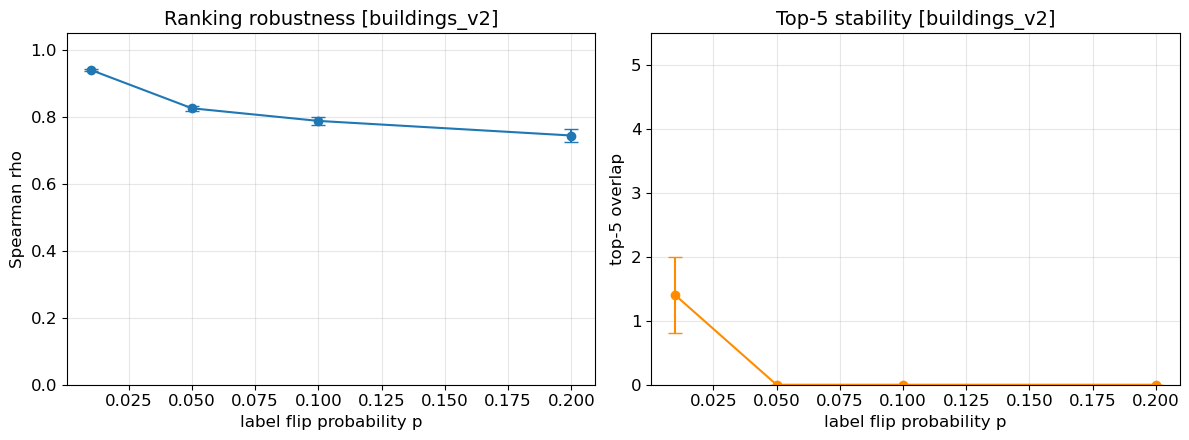

  Plot: cell_m8/M8_label_noise_buildings_v2_20260704_014026.png

  === points_v3plus ===
  Headline models: 210
  Universe: 104,130 unique samples
  Done in 234.9s
 p_flip  spearman_rho_mean  spearman_rho_std  top5_overlap_mean  mean_abs_delta_auc_mean
   0.01             0.9923            0.0027                4.9                   0.0053
   0.05             0.9898            0.0023                4.7                   0.0203
   0.10             0.9846            0.0054                4.7                   0.0332
   0.20             0.9730            0.0061                4.3                   0.0490
  Saved: cell_m8/M8_label_noise_reps_points_v3plus_20260704_014800.csv (1.8 KB)
  Saved: cell_m8/M8_label_noise_summary_points_v3plus_20260704_014800.csv (0.2 KB)


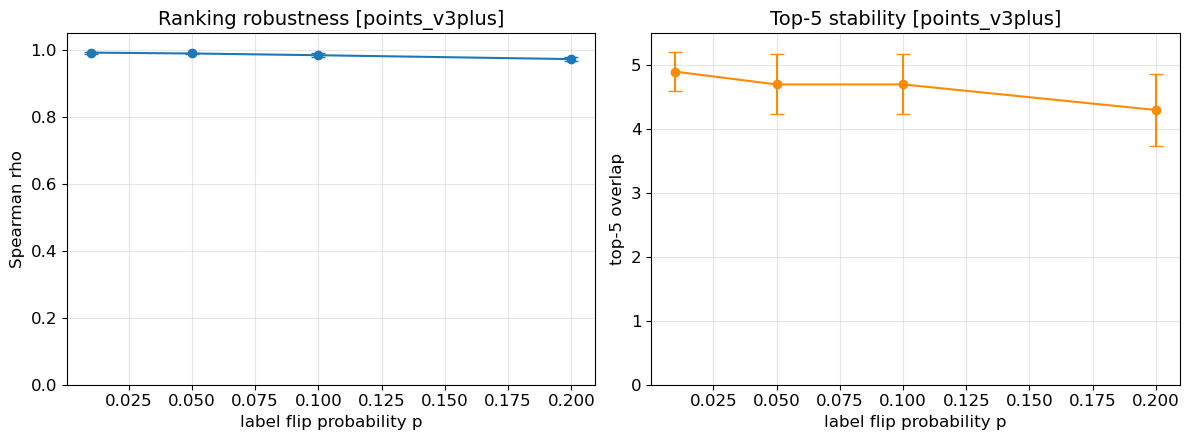

  Plot: cell_m8/M8_label_noise_points_v3plus_20260704_014800.png


In [10]:
# @title CELL M8: LABEL NOISE SENSITIVITY (PER GROUP)
from scipy.stats import spearmanr

print("=" * 70)
print(f"CELL M8: LABEL NOISE SENSITIVITY  "
      f"({LABEL_NOISE_N_REPS} reps x {len(LABEL_NOISE_RATES)} rates)")
print("=" * 70)

noise_all = {}

for grp_name, grp_oof in groups_loaded.items():
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    headline = sorted(ms.loc[(~ms['is_leaky']) & (~ms['is_degenerate']), 'model_id'])

    clean_ranking = ms[ms['model_id'].isin(headline)][['model_id', 'auc', 'modality_family']].dropna()
    clean_ranking = clean_ranking.sort_values('auc', ascending=False).reset_index(drop=True)
    clean_ranking['rank_clean'] = clean_ranking.index + 1
    print(f"  Headline models: {len(clean_ranking)}")

    model_arrays = {}
    for m in headline:
        g = grp_oof[grp_oof['model_id'] == m][[SAMPLE_ID_COL, 'y_true', 'y_proba']].drop_duplicates(SAMPLE_ID_COL)
        model_arrays[m] = {
            'sids': g[SAMPLE_ID_COL].values,
            'y_true': g['y_true'].values.astype(int),
            'y_proba': g['y_proba'].values,
        }

    all_sids = pd.unique(grp_oof[SAMPLE_ID_COL])
    print(f"  Universe: {len(all_sids):,} unique samples")

    rows = []
    t0 = time.time()
    for p in LABEL_NOISE_RATES:
        for rep in range(LABEL_NOISE_N_REPS):
            flip_mask = rng.random(len(all_sids)) < p
            flip_set = set(all_sids[flip_mask])

            noisy_ranking = []
            for m, arr in model_arrays.items():
                sids = arr['sids']
                yt = arr['y_true'].copy()
                ypr = arr['y_proba']
                flip_here = np.fromiter((s in flip_set for s in sids), dtype=bool, count=len(sids))
                yt[flip_here] = 1 - yt[flip_here]
                if 0 < yt.sum() < len(yt):
                    try:
                        a = float(roc_auc_score(yt, ypr))
                    except Exception:
                        a = np.nan
                else:
                    a = np.nan
                noisy_ranking.append({'model_id': m, 'auc_noisy': a})

            noisy_df = pd.DataFrame(noisy_ranking).dropna(subset=['auc_noisy'])
            merged = clean_ranking.merge(noisy_df, on='model_id', how='inner')
            if len(merged) < 3:
                continue
            rho_auc, _ = spearmanr(merged['auc'], merged['auc_noisy'])
            noisy_sorted = noisy_df.sort_values('auc_noisy', ascending=False).reset_index(drop=True)
            top5_clean = set(clean_ranking.head(5)['model_id'])
            top5_noisy = set(noisy_sorted.head(5)['model_id'])
            rows.append({
                'p_flip': p, 'rep': rep,
                'spearman_rho': round(rho_auc, 4),
                'top5_overlap': len(top5_clean & top5_noisy),
                'mean_abs_delta_auc': round(float(np.mean(np.abs(merged['auc'] - merged['auc_noisy']))), 4),
            })

    ndf = pd.DataFrame(rows)
    print(f"  Done in {time.time()-t0:.1f}s")

    summary = ndf.groupby('p_flip').agg(
        spearman_rho_mean=('spearman_rho', 'mean'),
        spearman_rho_std=('spearman_rho', 'std'),
        top5_overlap_mean=('top5_overlap', 'mean'),
        mean_abs_delta_auc_mean=('mean_abs_delta_auc', 'mean'),
    ).round(4).reset_index()
    print(summary.to_string(index=False))
    noise_all[grp_name] = summary
    save_result(ndf, f'M8_label_noise_reps_{grp_name}', 'cell_m8')
    save_result(summary, f'M8_label_noise_summary_{grp_name}', 'cell_m8')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax1.errorbar(summary['p_flip'], summary['spearman_rho_mean'],
                 yerr=summary['spearman_rho_std'], fmt='o-', capsize=5)
    ax1.set_xlabel('label flip probability p')
    ax1.set_ylabel('Spearman rho')
    ax1.set_title(f'Ranking robustness [{grp_name}]')
    ax1.set_ylim(0, 1.05); ax1.grid(alpha=0.3)

    ax2.errorbar(summary['p_flip'], summary['top5_overlap_mean'],
                 yerr=ndf.groupby('p_flip')['top5_overlap'].std().values,
                 fmt='o-', capsize=5, color='darkorange')
    ax2.set_xlabel('label flip probability p')
    ax2.set_ylabel('top-5 overlap')
    ax2.set_title(f'Top-5 stability [{grp_name}]')
    ax2.set_ylim(0, 5.5); ax2.grid(alpha=0.3)
    plt.tight_layout()
    save_fig(fig, f'M8_label_noise_{grp_name}', 'cell_m8')


# CELL M9: SUMMARY

In [11]:
# @title CELL M9: SUMMARY
print("=" * 70)
print("NB11c v5 SUMMARY")
print("=" * 70)

for grp_name in groups_loaded:
    print(f"\n  === {grp_name} ===")
    ms = model_sanity_all[grp_name]
    headline = ms[(~ms['is_leaky']) & (~ms['is_degenerate'])]
    print(f"  Models: {len(headline)} headline ({len(ms)} total)")

    if grp_name in per_model_stability_all:
        stab = per_model_stability_all[grp_name]
        print(f"  Per-fold CV: mean={stab['auc_cv'].mean():.3f}  range={stab['auc_range'].mean():.3f}")

    if grp_name in kappa_ci_all:
        kdf = kappa_ci_all[grp_name].dropna(subset=['kappa_ci_width'])
        if len(kdf) > 0:
            print(f"  Pairwise kappa: mean={kdf['kappa_mean'].mean():.3f}  "
                  f"CI_width={kdf['kappa_ci_width'].median():.4f}")

    if grp_name in jac_ci_all:
        jdf = jac_ci_all[grp_name]
        if len(jdf) > 0:
            print(f"  Jaccard FN: mean={jdf['jac_fn_mean'].mean():.3f}  "
                  f"FP: mean={jdf['jac_fp_mean'].mean():.3f}")

    if grp_name in fleiss_results:
        fr = fleiss_results[grp_name]
        print(f"  Fleiss kappa: {fr['kappa_point']:.4f}  CI=[{fr['kappa_lo']:.4f}, {fr['kappa_hi']:.4f}]")

    if grp_name in leakage_all:
        ldf = leakage_all[grp_name]
        n_sig = int(ldf['ci_excludes_zero'].sum())
        print(f"  Leakage pairs: {len(ldf)} tested, {n_sig} significant")
        if len(ldf) > 0:
            print(f"    Max delta: {ldf['delta_point'].max():+.4f}  "
                  f"({ldf.loc[ldf['delta_point'].idxmax(), 'leaky_model']})")

    if grp_name in noise_all:
        ns = noise_all[grp_name]
        r5 = ns[ns['p_flip'] == 0.05]
        if len(r5) > 0:
            print(f"  Label noise @5%: rho={r5.iloc[0]['spearman_rho_mean']:.3f}  "
                  f"top5={r5.iloc[0]['top5_overlap_mean']:.1f}/5")

    # modality family summary
    print(f"\n  Modality family AUC [{grp_name}]:")
    for fam in ['SAR', 'MS', 'multimodal', 'other']:
        sub = headline[headline['modality_family'] == fam]
        if len(sub) > 0:
            print(f"    {fam:15s}: n={len(sub):3d}  median={sub['auc'].median():.3f}  "
                  f"max={sub['auc'].max():.3f}")

master = {
    'notebook': 'NB11c_v5',
    'groups': list(groups_loaded.keys()),
    'b_bootstrap': B_BOOTSTRAP,
    'random_state': RANDOM_STATE,
}
save_result(master, 'nb11c_summary', 'cell_m9', fmt='json')
print(f"\n  Done.")


NB11c v5 SUMMARY

  === buildings_v2 ===
  Models: 304 headline (342 total)
  Per-fold CV: mean=0.140  range=0.206
  Pairwise kappa: mean=0.610  CI_width=0.0044
  Jaccard FN: mean=0.545  FP: mean=0.544
  Fleiss kappa: 0.6218  CI=[0.6204, 0.6230]
  Leakage pairs: 2 tested, 2 significant
    Max delta: +0.1018  (D1i_allblocks_random)
  Label noise @5%: rho=0.826  top5=0.0/5

  Modality family AUC [buildings_v2]:
    SAR            : n= 69  median=0.625  max=0.846
    MS             : n= 30  median=0.659  max=0.818
    multimodal     : n= 64  median=0.748  max=0.865
    other          : n=141  median=0.594  max=0.843

  === points_v3plus ===
  Models: 210 headline (219 total)
  Per-fold CV: mean=0.056  range=0.082
  Pairwise kappa: mean=0.497  CI_width=0.0142
  Jaccard FN: mean=0.561  FP: mean=0.497
  Leakage pairs: 2 tested, 2 significant
    Max delta: +0.1104  (D1i_allblocks_random)
  Label noise @5%: rho=0.990  top5=4.7/5

  Modality family AUC [points_v3plus]:
    SAR            : n=